# Exploration embeddings de seances

Ce notebook explore des **representations vectorielles de seances** pour deux usages :

- **classification** de seance (facile / moderee / dure / tres dure)
- **recommandation** par similarite entre seances

L'idee centrale ici est de commencer par un **embedding tabulaire** robuste construit a partir des metriques de seance, puis d'explorer en option un **embedding texte** via Ollama pour comparer les comportements.

Les visualisations couvrent :

- distributions et outliers
- correlation entre variables
- projection 2D (PCA, t-SNE)
- clustering KMeans
- profils moyens par cluster
- score heuristique de difficulte
- voisins proches entre seances


> Filtre actif : seules les séances à partir du **14 septembre 2025** sont retenues, car les données cardio antérieures ne sont pas assez fiables.

In [21]:
from pathlib import Path
import os
import sys
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from dotenv import load_dotenv

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


In [22]:
# Resolution robuste des chemins quand le notebook est lance depuis exploration/
CWD = Path.cwd().resolve()
if (CWD / "core").exists():
    BACKEND_ROOT = CWD
elif (CWD.parent / "core").exists():
    BACKEND_ROOT = CWD.parent
else:
    raise RuntimeError(f"Impossible de localiser le backend depuis {CWD}")

load_dotenv(BACKEND_ROOT / ".env")

DATABASE_URL = os.getenv("DATABASE_URL")
DEFAULT_USER_ID = os.getenv("DEFAULT_USER_ID") or os.getenv("USER_ID")

if not DATABASE_URL:
    raise RuntimeError("DATABASE_URL missing")
if not DEFAULT_USER_ID:
    raise RuntimeError("DEFAULT_USER_ID or USER_ID missing")

engine = create_engine(DATABASE_URL)

print("BACKEND_ROOT:", BACKEND_ROOT)
print("DEFAULT_USER_ID:", DEFAULT_USER_ID)
pd.read_sql("SELECT 1 AS ok", engine)


BACKEND_ROOT: /Users/albanecoiffe/Library/Mobile Documents/com~apple~CloudDocs/Documents/Projet/HealthCoach/HealthCoachBackend
DEFAULT_USER_ID: f90a87bf-2104-4456-8a54-b42c307337e7


,ok
0,1


In [23]:
query = """
SELECT
    user_id,
    start_time,
    distance_km,
    duration_min,
    avg_hr,
    z1_min,
    z2_min,
    z3_min,
    z4_min,
    z5_min,
    elevation_m,
    active_kcal
FROM run_sessions
WHERE user_id = %(user_id)s
ORDER BY start_time
"""

sessions = pd.read_sql(query, engine, params={"user_id": DEFAULT_USER_ID})
sessions["start_time"] = pd.to_datetime(sessions["start_time"], utc=True, errors="coerce")

MIN_SESSION_DATE = pd.Timestamp("2025-09-14", tz="UTC")
sessions = sessions[sessions["start_time"] >= MIN_SESSION_DATE].copy()

print(f"{len(sessions)} seances chargees a partir du 2025-09-14")
sessions.tail(3)


98 seances chargees a partir du 2025-09-14


,user_id,start_time,distance_km,duration_min,avg_hr,z1_min,z2_min,z3_min,z4_min,z5_min,elevation_m,active_kcal
359,f90a87bf-2104-4456-8a54-b42c307337e7,2026-04-19 07:47:16+00:00,2.212506,16.207430,133.238683,16.180234,0.000000,0.000000,0.0,0.0,2.54,92.725744
360,f90a87bf-2104-4456-8a54-b42c307337e7,2026-04-21 16:10:41+00:00,4.100121,29.179091,149.134236,6.463035,20.880391,2.192036,0.0,0.0,10.72,185.245584
361,f90a87bf-2104-4456-8a54-b42c307337e7,2026-04-23 04:27:20+00:00,4.287987,30.585126,151.501636,4.515493,23.280385,2.760050,0.0,0.0,10.25,199.802994


In [24]:
def build_session_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    zone_cols = ["z1_min", "z2_min", "z3_min", "z4_min", "z5_min"]
    for col in zone_cols:
        out[col] = out[col].fillna(0.0)

    out = out.dropna(subset=["start_time", "distance_km", "duration_min"])
    out = out[(out["distance_km"] > 0) & (out["duration_min"] > 0)].copy()

    out["date"] = out["start_time"].dt.tz_convert("Europe/Paris").dt.date
    out["weekday"] = out["start_time"].dt.tz_convert("Europe/Paris").dt.day_name()
    out["hour_local"] = out["start_time"].dt.tz_convert("Europe/Paris").dt.hour

    out["pace_min_per_km"] = out["duration_min"] / out["distance_km"]
    out["speed_kmh"] = out["distance_km"] / (out["duration_min"] / 60.0)

    out["zone_total_min"] = out[zone_cols].sum(axis=1)
    out["low_intensity_min"] = out["z1_min"] + out["z2_min"] + out["z3_min"]
    out["high_intensity_min"] = out["z4_min"] + out["z5_min"]

    safe_zone_total = out["zone_total_min"].replace(0, np.nan)
    for col in zone_cols:
        out[col.replace("_min", "_pct")] = out[col] / safe_zone_total

    out["high_intensity_ratio"] = out["high_intensity_min"] / safe_zone_total
    out["low_intensity_ratio"] = out["low_intensity_min"] / safe_zone_total

    out["elevation_m"] = out["elevation_m"].fillna(0.0)
    out["active_kcal"] = out["active_kcal"].fillna(0.0)
    out["avg_hr"] = out["avg_hr"].fillna(out["avg_hr"].median())

    out["elevation_per_km"] = out["elevation_m"] / out["distance_km"].replace(0, np.nan)
    out["kcal_per_km"] = out["active_kcal"] / out["distance_km"].replace(0, np.nan)
    out["kcal_per_min"] = out["active_kcal"] / out["duration_min"].replace(0, np.nan)

    out["load_proxy"] = out["duration_min"] * (1 + 2 * out["high_intensity_ratio"].fillna(0.0))

    # Quantile-rank score de difficulte : interpretable, stable, sans label manuel.
    rank_features = {
        "duration_rank": out["duration_min"].rank(pct=True),
        "high_intensity_rank": out["high_intensity_ratio"].fillna(0).rank(pct=True),
        "avg_hr_rank": out["avg_hr"].rank(pct=True),
        "elevation_rank": out["elevation_per_km"].fillna(0).rank(pct=True),
        "speed_rank": out["speed_kmh"].rank(pct=True),
    }
    for name, values in rank_features.items():
        out[name] = values

    out["difficulty_score"] = (
        0.30 * out["duration_rank"] +
        0.25 * out["high_intensity_rank"] +
        0.20 * out["avg_hr_rank"] +
        0.15 * out["elevation_rank"] +
        0.10 * out["speed_rank"]
    )

    bins = out["difficulty_score"].quantile([0, 0.25, 0.50, 0.75, 1.0]).to_list()
    # evite les bornes dupliquees quand l'echantillon est petit
    bins = np.unique(bins)
    labels = ["facile", "moderee", "dure", "tres_dure"][: max(len(bins) - 1, 1)]
    if len(bins) > 1:
        out["difficulty_label"] = pd.cut(
            out["difficulty_score"],
            bins=bins,
            labels=labels,
            include_lowest=True,
            duplicates="drop",
        ).astype(str)
    else:
        out["difficulty_label"] = "moderee"

    return out

features = build_session_features(sessions)
features.head(3)


,user_id,start_time,distance_km,duration_min,avg_hr,z1_min,z2_min,z3_min,z4_min,z5_min,elevation_m,active_kcal,date,weekday,hour_local,pace_min_per_km,speed_kmh,zone_total_min,low_intensity_min,high_intensity_min,z1_pct,z2_pct,z3_pct,z4_pct,z5_pct,high_intensity_ratio,low_intensity_ratio,elevation_per_km,kcal_per_km,kcal_per_min,load_proxy,duration_rank,high_intensity_rank,avg_hr_rank,elevation_rank,speed_rank,difficulty_score,difficulty_label
264,f90a87bf-2104-4456-8a54-b42c307337e7,2025-09-14 07:56:56+00:00,1.006600,6.514466,135.106013,4.183333,3.316667,0.000000,0.000000,0.0,2.56,42.264026,2025-09-14,Sunday,9,6.471751,9.271062,7.500000,7.500000,0.000000,0.557778,0.442222,0.000000,0.000000,0.0,0.000000,1.000000,2.543214,41.986901,6.487719,6.514466,0.030612,0.280612,0.081633,0.418367,0.418367,0.200255,facile
265,f90a87bf-2104-4456-8a54-b42c307337e7,2025-09-14 08:26:12+00:00,5.052251,32.672392,160.876990,0.000000,21.250000,12.195833,0.000000,0.0,8.51,223.886737,2025-09-14,Sunday,10,6.466898,9.278018,33.445833,33.445833,0.000000,0.000000,0.635356,0.364644,0.000000,0.0,0.000000,1.000000,1.684398,44.314258,6.852475,32.672392,0.255102,0.280612,0.765306,0.224490,0.448980,0.378316,moderee
266,f90a87bf-2104-4456-8a54-b42c307337e7,2025-09-14 08:59:44+00:00,3.013890,15.612216,176.997594,0.000000,0.000000,5.983508,6.970833,0.0,4.65,132.558014,2025-09-14,Sunday,10,5.180089,11.582813,12.954342,5.983508,6.970833,0.000000,0.000000,0.461892,0.538108,0.0,0.538108,0.461892,1.542857,43.982372,8.490660,32.414328,0.051020,0.979592,1.000000,0.193878,1.000000,0.589286,dure


In [25]:
overview_cols = [
    "distance_km", "duration_min", "pace_min_per_km", "speed_kmh", "avg_hr",
    "high_intensity_ratio", "elevation_per_km", "active_kcal", "load_proxy", "difficulty_score"
]

summary = features[overview_cols].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T
summary


,count,mean,std,min,10%,25%,50%,75%,90%,max
distance_km,98.0,9.538465,6.344537,0.499228,3.744274,5.014379,8.271826,12.080093,17.119892,42.787576
duration_min,98.0,59.310403,36.120450,3.272444,24.860201,32.986161,52.363741,74.097906,100.265228,245.551146
pace_min_per_km,98.0,6.420049,0.544548,5.180089,5.802444,6.031748,6.405726,6.689080,7.137893,8.347466
speed_kmh,98.0,9.410497,0.777539,7.187810,8.405853,8.969851,9.366619,9.947367,10.340471,11.582813
avg_hr,98.0,152.297446,11.299069,109.916447,138.609729,145.489933,153.211772,160.200135,165.527378,176.997594
high_intensity_ratio,98.0,0.106377,0.176535,0.000000,0.000000,0.000000,0.000000,0.177753,0.323493,0.904433
elevation_per_km,98.0,3.751386,2.627542,0.000000,1.180212,1.868718,3.198799,5.473163,6.684767,12.110290
active_kcal,98.0,435.440151,288.737159,21.481000,164.328045,220.137012,381.502171,573.428304,774.969409,1924.223339
load_proxy,98.0,77.636775,73.604126,3.272444,27.140137,32.986161,60.178388,99.183343,129.878065,586.766300
difficulty_score,98.0,0.505102,0.203430,0.119133,0.241276,0.321811,0.526020,0.661862,0.767806,0.919388


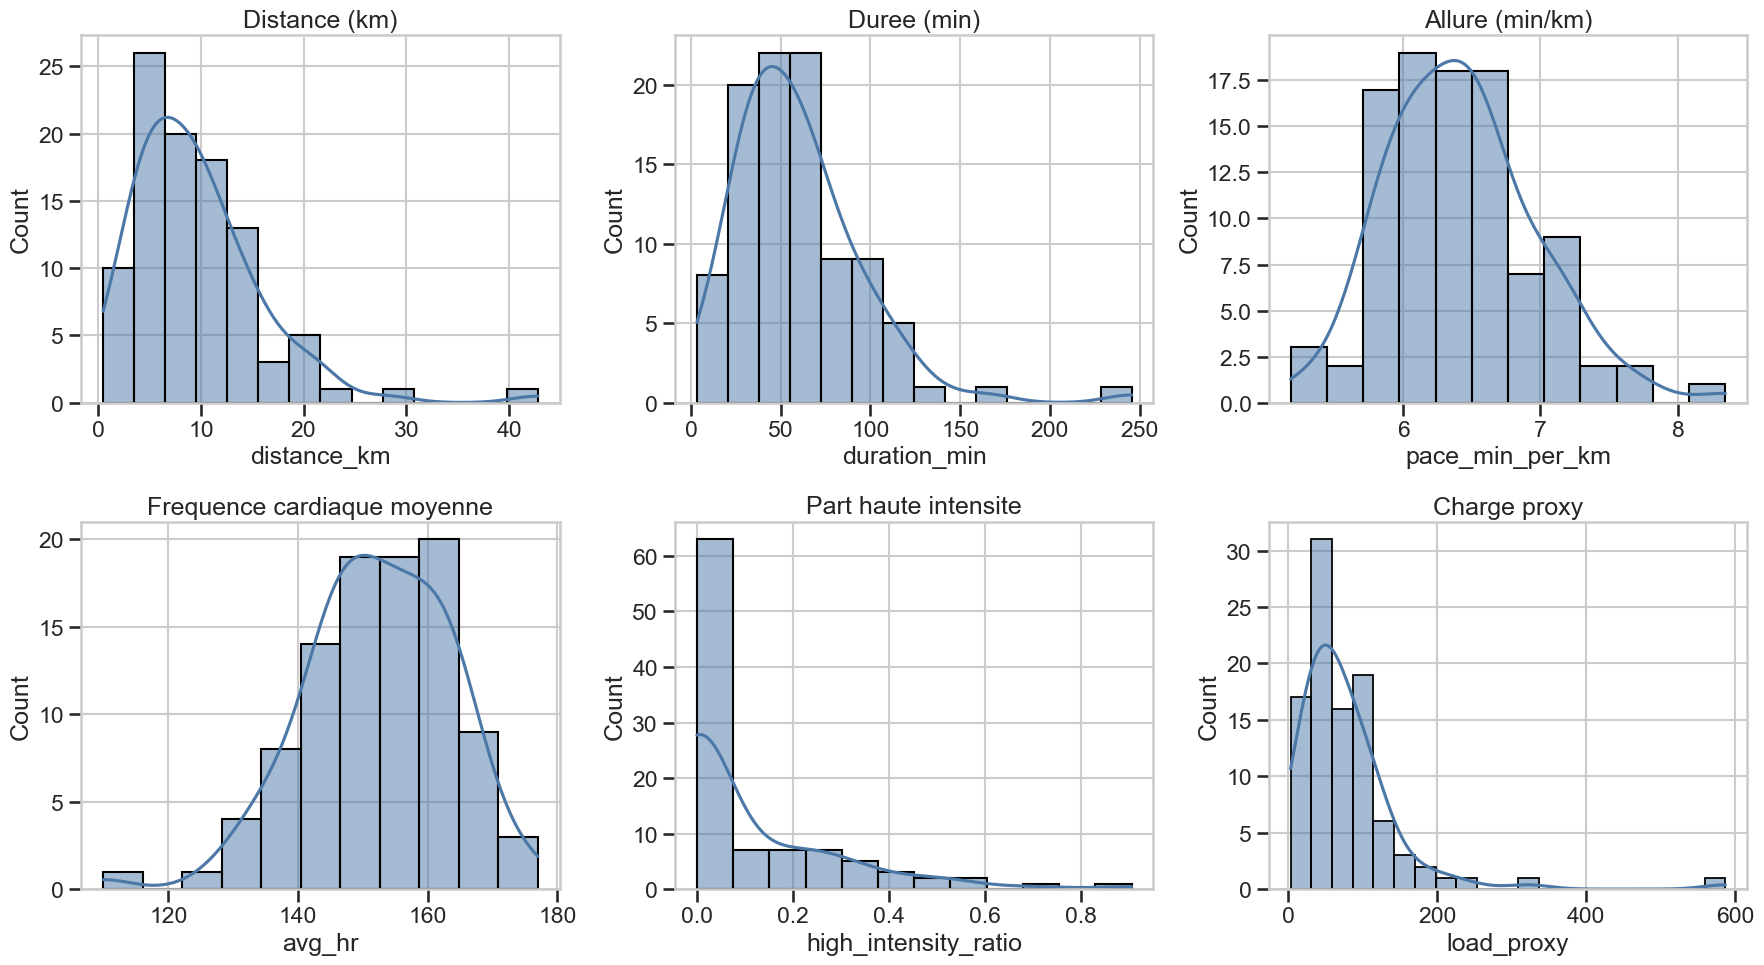

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_specs = [
    ("distance_km", "Distance (km)"),
    ("duration_min", "Duree (min)"),
    ("pace_min_per_km", "Allure (min/km)"),
    ("avg_hr", "Frequence cardiaque moyenne"),
    ("high_intensity_ratio", "Part haute intensite"),
    ("load_proxy", "Charge proxy"),
]

for ax, (col, title) in zip(axes.flat, plot_specs):
    sns.histplot(features[col], kde=True, ax=ax, color="#4C78A8")
    ax.set_title(title)

plt.tight_layout()
plt.show()


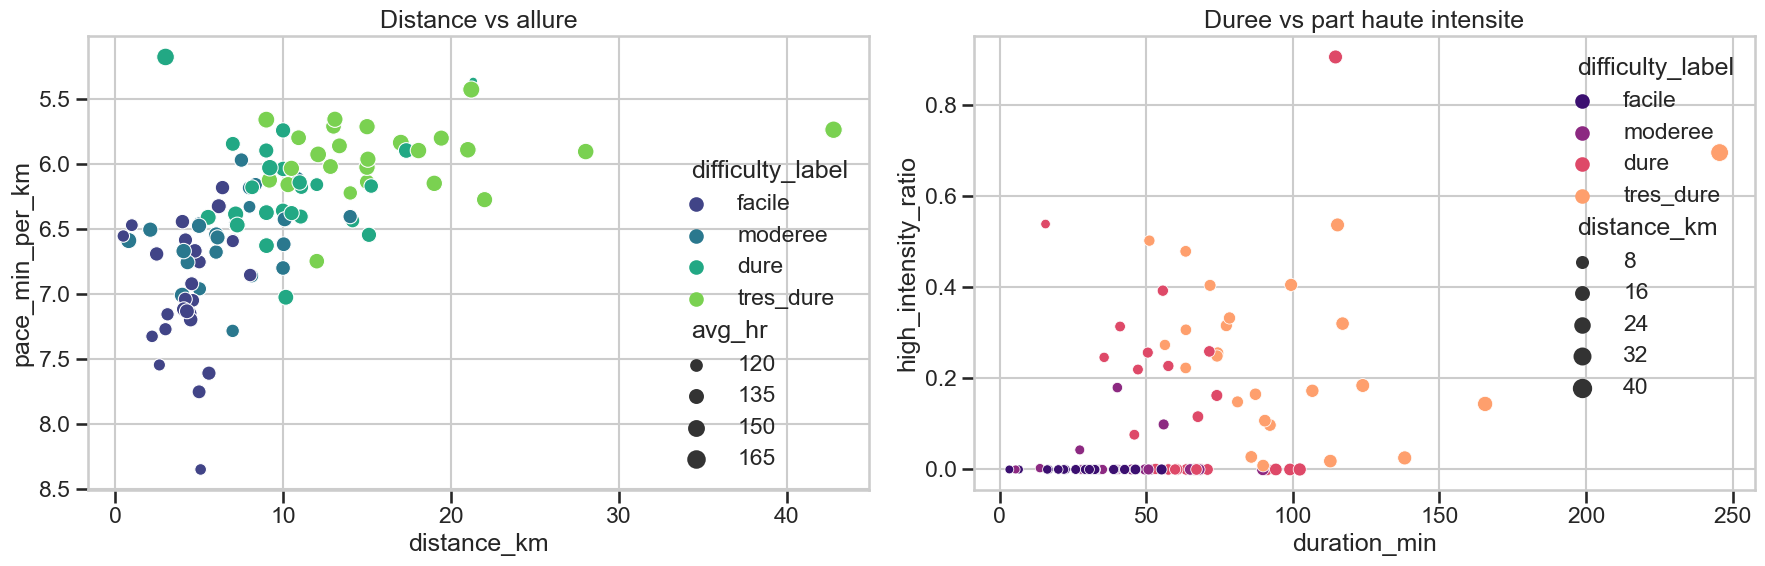

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.scatterplot(
    data=features,
    x="distance_km",
    y="pace_min_per_km",
    hue="difficulty_label",
    size="avg_hr",
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title("Distance vs allure")
axes[0].invert_yaxis()

sns.scatterplot(
    data=features,
    x="duration_min",
    y="high_intensity_ratio",
    hue="difficulty_label",
    size="distance_km",
    palette="magma",
    ax=axes[1],
)
axes[1].set_title("Duree vs part haute intensite")

plt.tight_layout()
plt.show()


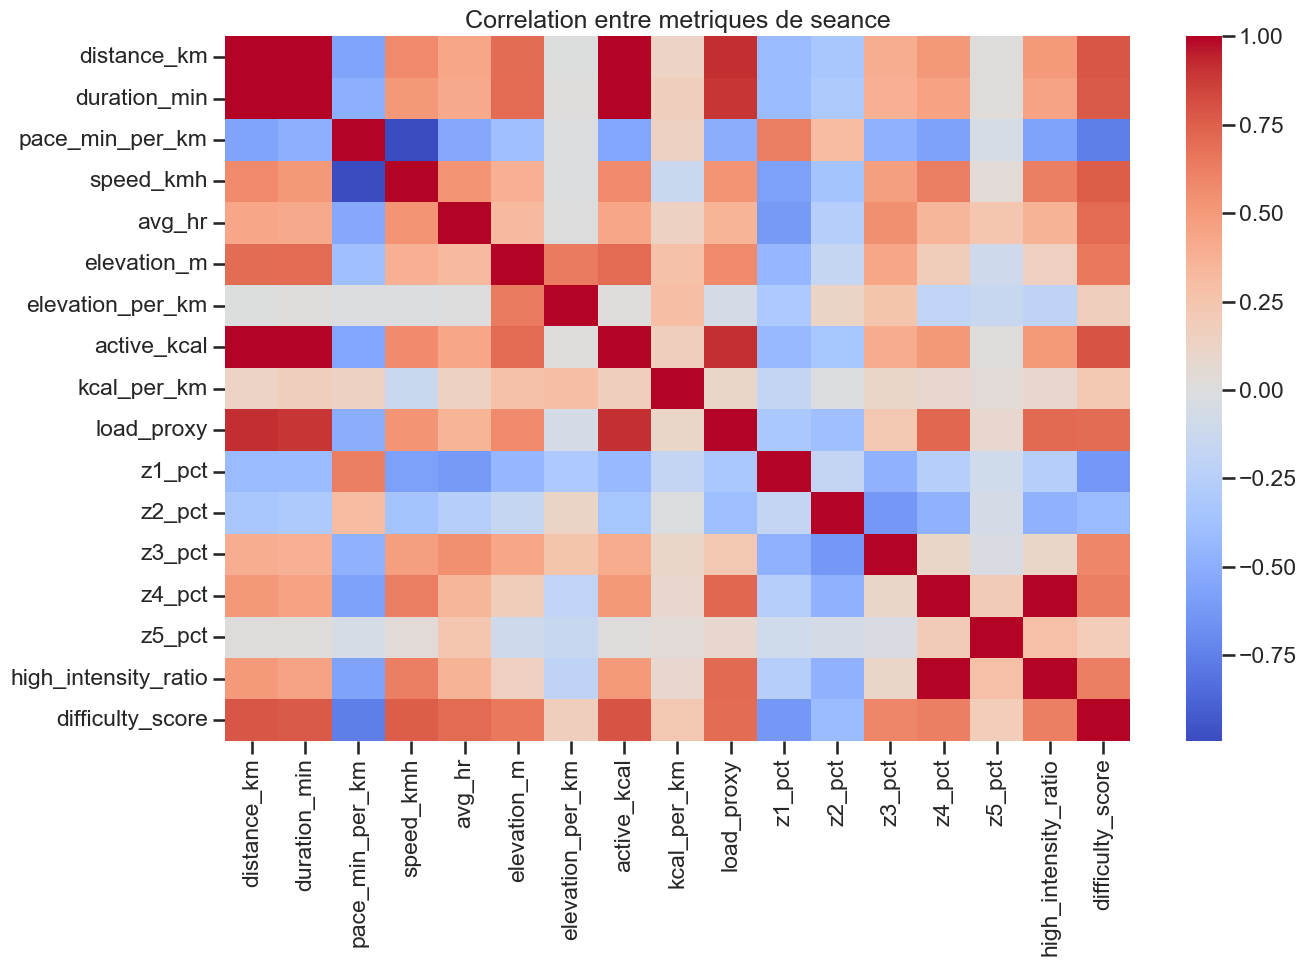

In [28]:
corr_cols = [
    "distance_km", "duration_min", "pace_min_per_km", "speed_kmh", "avg_hr",
    "elevation_m", "elevation_per_km", "active_kcal", "kcal_per_km", "load_proxy",
    "z1_pct", "z2_pct", "z3_pct", "z4_pct", "z5_pct", "high_intensity_ratio", "difficulty_score"
]

corr = features[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation entre metriques de seance")
plt.tight_layout()
plt.show()


In [29]:
embedding_features = [
    "distance_km", "duration_min", "pace_min_per_km", "speed_kmh", "avg_hr",
    "elevation_per_km", "kcal_per_km", "z1_pct", "z2_pct", "z3_pct", "z4_pct", "z5_pct",
    "high_intensity_ratio", "load_proxy"
]

X = features[embedding_features].replace([np.inf, -np.inf], np.nan).fillna(0.0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
features["pca_1"] = X_pca[:, 0]
features["pca_2"] = X_pca[:, 1]

print("Variance expliquee PCA:", pca.explained_variance_ratio_, "total=", pca.explained_variance_ratio_.sum())


Variance expliquee PCA: [0.43129414 0.13941293] total= 0.5707070718267584


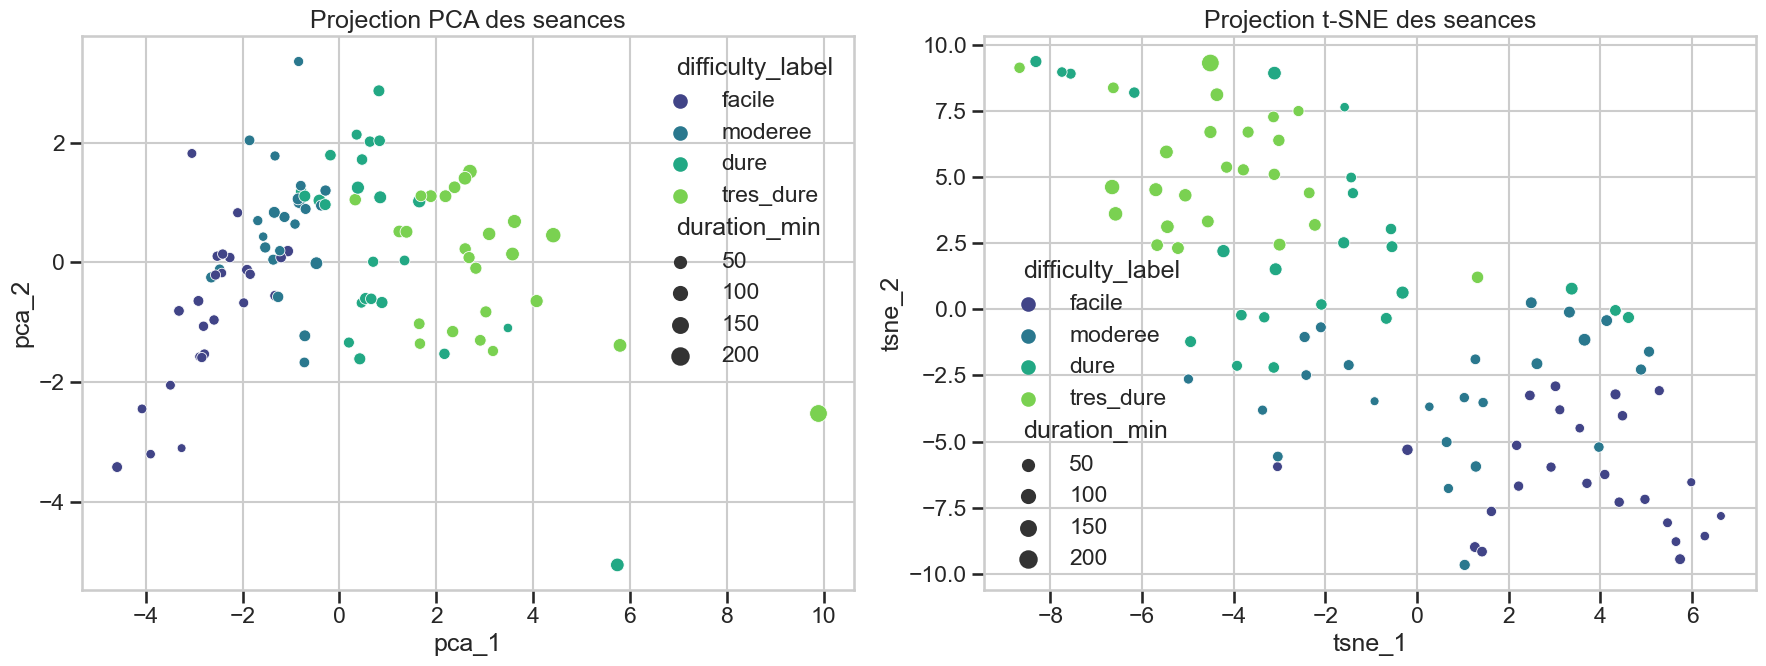

In [30]:
tsne_perplexity = max(5, min(30, len(features) // 4))
tsne = TSNE(
    n_components=2,
    perplexity=tsne_perplexity,
    learning_rate="auto",
    init="pca",
    random_state=42,
)
X_tsne = tsne.fit_transform(X_scaled)
features["tsne_1"] = X_tsne[:, 0]
features["tsne_2"] = X_tsne[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(
    data=features,
    x="pca_1",
    y="pca_2",
    hue="difficulty_label",
    size="duration_min",
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title("Projection PCA des seances")

sns.scatterplot(
    data=features,
    x="tsne_1",
    y="tsne_2",
    hue="difficulty_label",
    size="duration_min",
    palette="viridis",
    ax=axes[1],
)
axes[1].set_title("Projection t-SNE des seances")

plt.tight_layout()
plt.show()


In [31]:
candidate_ks = list(range(2, min(7, len(features))))
model_selection_rows = []

for k in candidate_ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    model_selection_rows.append({"k": k, "silhouette": sil, "inertia": km.inertia_})

cluster_search = pd.DataFrame(model_selection_rows)
cluster_search


,k,silhouette,inertia
0,2,0.269740,980.500790
1,3,0.233580,838.458518
2,4,0.238904,732.024776
3,5,0.224091,631.605961
4,6,0.227510,550.398414


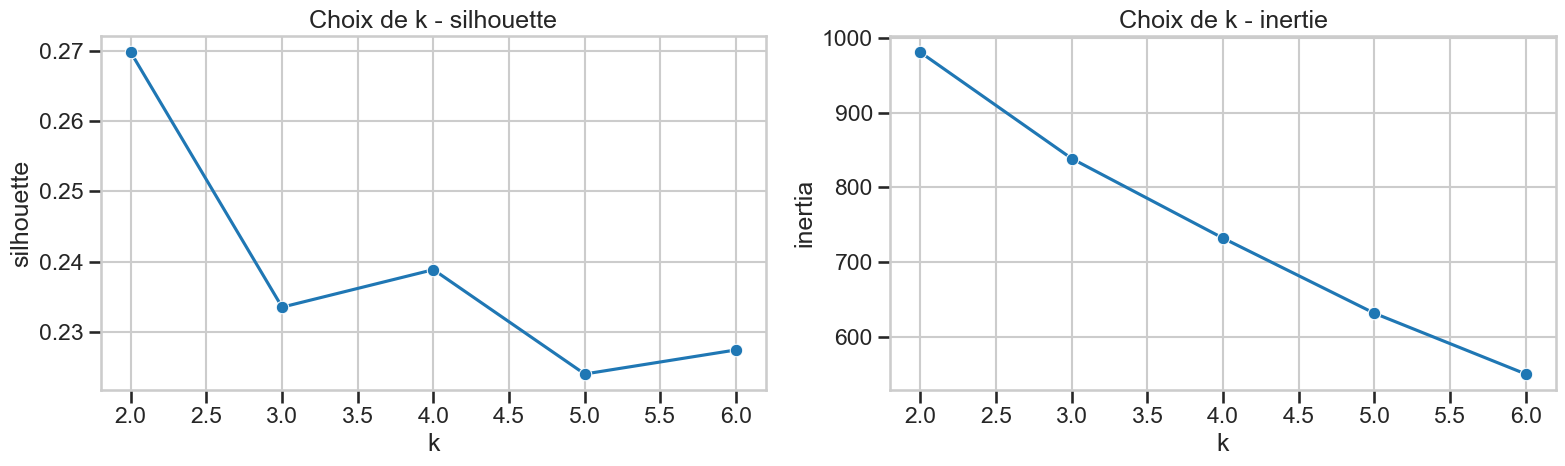

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=cluster_search, x="k", y="silhouette", marker="o", ax=axes[0])
axes[0].set_title("Choix de k - silhouette")

sns.lineplot(data=cluster_search, x="k", y="inertia", marker="o", ax=axes[1])
axes[1].set_title("Choix de k - inertie")

plt.tight_layout()
plt.show()


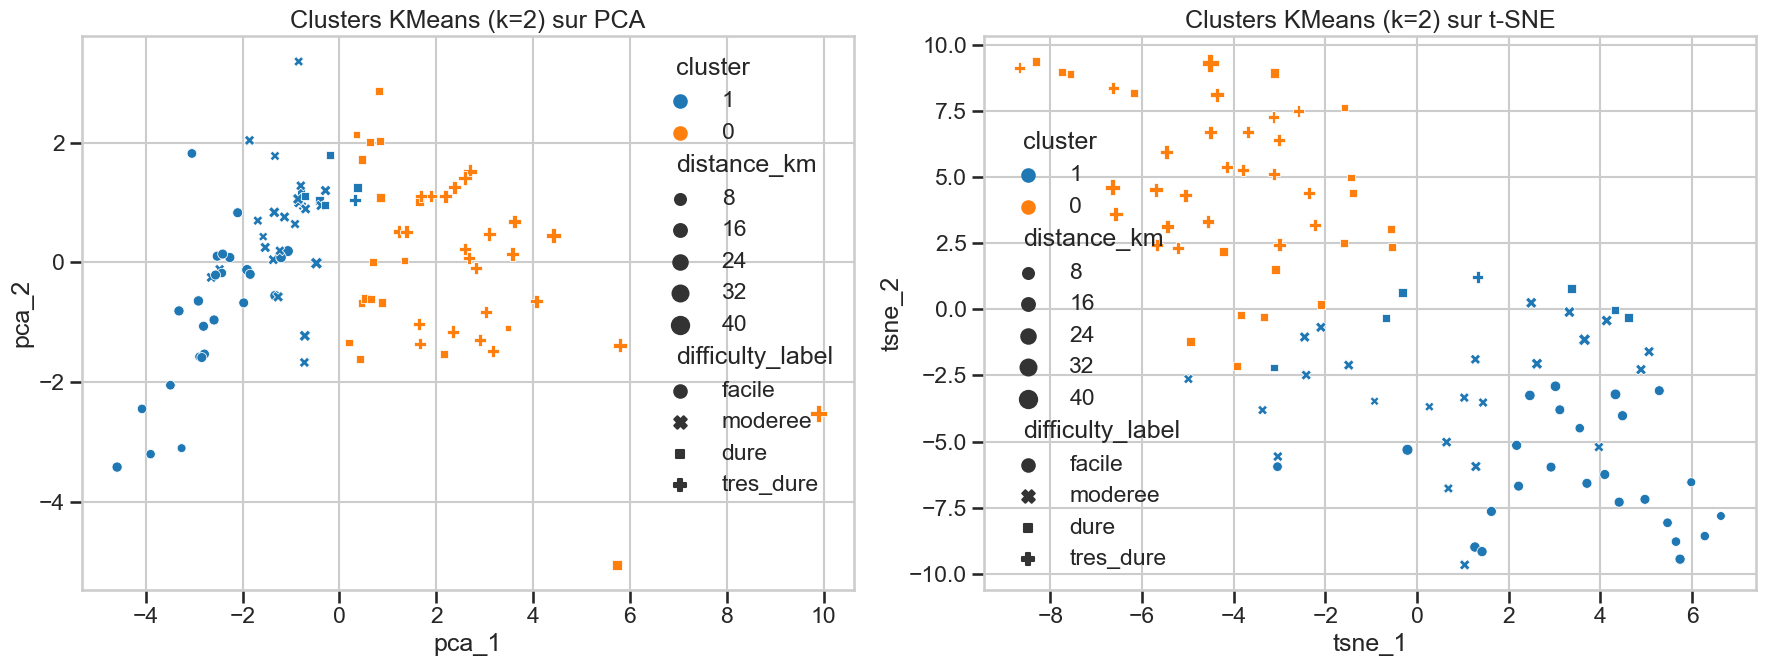

In [33]:
best_k = int(cluster_search.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]["k"])
clusterer = KMeans(n_clusters=best_k, n_init=20, random_state=42)
features["cluster"] = clusterer.fit_predict(X_scaled).astype(str)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(
    data=features,
    x="pca_1",
    y="pca_2",
    hue="cluster",
    style="difficulty_label",
    size="distance_km",
    palette="tab10",
    ax=axes[0],
)
axes[0].set_title(f"Clusters KMeans (k={best_k}) sur PCA")

sns.scatterplot(
    data=features,
    x="tsne_1",
    y="tsne_2",
    hue="cluster",
    style="difficulty_label",
    size="distance_km",
    palette="tab10",
    ax=axes[1],
)
axes[1].set_title(f"Clusters KMeans (k={best_k}) sur t-SNE")

plt.tight_layout()
plt.show()


In [34]:
profile_cols = [
    "distance_km", "duration_min", "pace_min_per_km", "avg_hr", "elevation_per_km",
    "high_intensity_ratio", "load_proxy", "difficulty_score"
]

cluster_profile = features.groupby("cluster")[profile_cols].mean().sort_index()
cluster_profile


,distance_km,duration_min,pace_min_per_km,avg_hr,elevation_per_km,high_intensity_ratio,load_proxy,difficulty_score
cluster,,,,,,,,
0,13.829789,82.285164,5.987736,159.794621,3.650561,0.236959,123.810093,0.697291
1,6.319971,42.079332,6.744283,146.674565,3.827004,0.008440,43.006787,0.360960


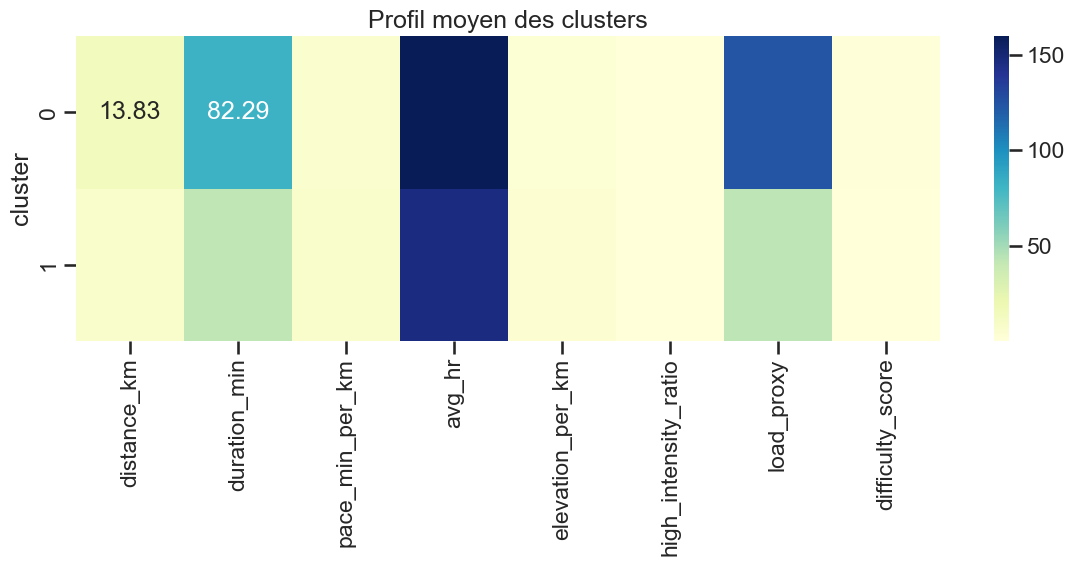

In [35]:
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profile, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Profil moyen des clusters")
plt.tight_layout()
plt.show()


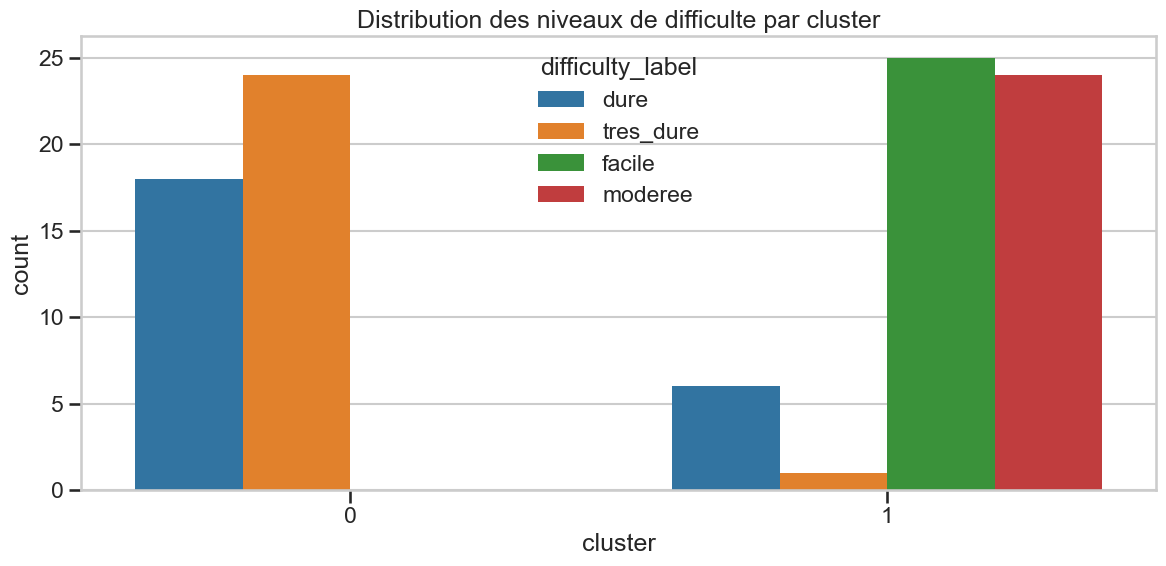

In [36]:
cluster_summary = (
    features.groupby(["cluster", "difficulty_label"]).size().rename("count").reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=cluster_summary, x="cluster", y="count", hue="difficulty_label")
plt.title("Distribution des niveaux de difficulte par cluster")
plt.tight_layout()
plt.show()


In [39]:
nn = NearestNeighbors(n_neighbors=min(6, len(features)), metric="euclidean")
nn.fit(X_scaled)

def nearest_sessions(idx: int, n_neighbors: int = 5) -> pd.DataFrame:
    distances, indices = nn.kneighbors(X_scaled[idx:idx+1], n_neighbors=min(n_neighbors + 1, len(features)))
    out = features.iloc[indices[0]].copy()
    out["neighbor_distance"] = distances[0]
    return out[[
        "start_time", "distance_km", "duration_min", "pace_min_per_km", "avg_hr",
        "high_intensity_ratio", "difficulty_label", "cluster", "neighbor_distance"
    ]]

# Convert label index to positional index
hard_label_idx = features["difficulty_score"].idxmax()
hard_idx = features.index.get_loc(hard_label_idx)
nearest_sessions(hard_idx, n_neighbors=5)

,start_time,distance_km,duration_min,pace_min_per_km,avg_hr,high_intensity_ratio,difficulty_label,cluster,neighbor_distance
357,2026-04-12 08:38:35+00:00,42.787576,245.551146,5.738842,174.794828,0.694794,tres_dure,0,0.000000
342,2026-03-08 08:36:40+00:00,21.218241,115.223184,5.430383,171.314758,0.536160,tres_dure,0,7.286368
348,2026-03-22 07:23:36+00:00,28.030736,165.565045,5.906554,166.223894,0.143693,tres_dure,0,7.741847
319,2026-01-10 08:20:21+00:00,17.022094,99.382084,5.838417,169.785655,0.404677,tres_dure,0,8.441600
322,2026-01-17 08:43:18+00:00,19.013623,116.943431,6.150508,165.370873,0.319792,tres_dure,0,8.539151
325,2026-01-24 08:07:13+00:00,21.013314,123.826407,5.892760,166.759633,0.184086,tres_dure,0,8.710859


              precision    recall  f1-score   support

           0       0.71      0.83      0.77         6
           1       0.75      0.50      0.60         6
           2       0.67      0.67      0.67         6
           3       0.75      0.86      0.80         7

    accuracy                           0.72        25
   macro avg       0.72      0.71      0.71        25
weighted avg       0.72      0.72      0.71        25



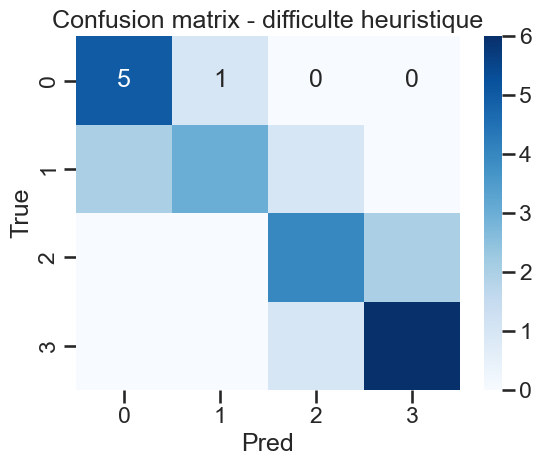

In [40]:
label_order = ["facile", "moderee", "dure", "tres_dure"]
label_map = {label: idx for idx, label in enumerate([l for l in label_order if l in set(features["difficulty_label"])])}

y = features["difficulty_label"].map(label_map)

if y.nunique() >= 2 and len(features) >= 12:
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.25, random_state=42, stratify=y
    )
    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion matrix - difficulte heuristique")
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()
else:
    print("Pas assez de donnees ou de classes pour une classification testable proprement.")


## Option : embedding texte via Ollama

Si tu veux comparer un embedding **tabulaire** et un embedding **texte**, tu peux decrire chaque seance avec une phrase standardisee, puis demander un embedding a `nomic-embed-text` via Ollama.

L'interet :

- injecter plus facilement du contexte symbolique
- preparer un futur pipeline RAG / nearest neighbors textuels
- comparer la separation des groupes vs l'embedding tabulaire


In [41]:
import requests

OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL", "http://localhost:11434")
EMBED_MODEL = os.getenv("OLLAMA_EMBED_MODEL", "nomic-embed-text")

def format_session_text(row: pd.Series) -> str:
    return (
        f"Seance de course de {row['distance_km']:.1f} km en {row['duration_min']:.0f} min, "
        f"allure moyenne {row['pace_min_per_km']:.2f} min/km, FC moyenne {row['avg_hr']:.0f} bpm, "
        f"intensite haute {100 * row['high_intensity_ratio']:.0f} %, denivele par km {row['elevation_per_km']:.1f} m/km."
    )

def ollama_embed(text: str, model: str = EMBED_MODEL, base_url: str = OLLAMA_BASE_URL) -> np.ndarray:
    r = requests.post(
        f"{base_url.rstrip('/')}/api/embeddings",
        json={"model": model, "prompt": text},
        timeout=30,
    )
    r.raise_for_status()
    return np.array(r.json()["embedding"], dtype=float)

session_texts = features.apply(format_session_text, axis=1)
session_texts.head(3)


264    Seance de course de 1.0 km en 7 min, allure mo...
265    Seance de course de 5.1 km en 33 min, allure m...
266    Seance de course de 3.0 km en 16 min, allure m...
dtype: object

In [42]:
# Debloquer cette cellule si Ollama tourne localement.
# text_embeddings = np.vstack([ollama_embed(text) for text in session_texts])
# text_pca = PCA(n_components=2, random_state=42).fit_transform(text_embeddings)
#
# plt.figure(figsize=(10, 7))
# sns.scatterplot(x=text_pca[:, 0], y=text_pca[:, 1], hue=features["difficulty_label"], palette="viridis")
# plt.title("Projection PCA des embeddings texte de seances")
# plt.tight_layout()
# plt.show()


## Lecture rapide des resultats attendus

Si ce notebook te donne des groupes stables, tu peux ensuite :

1. **nommer les clusters** a la main (`footing facile`, `sortie longue`, `tempo`, `intense`)
2. utiliser ces clusters comme **labels faibles** pour de la classification supervisee
3. recommander une seance future par **similarite + contexte de charge recente**
4. comparer les embeddings tabulaires et les embeddings texte

Pour une version prod, je partirais d'abord sur :

- embedding tabulaire standardise
- clustering + voisins proches
- score heuristique de difficulte
- puis seulement apres un modele supervise si les labels tiennent dans le temps
